## XGBoost Classification on Clustered Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/country_data_clustered.csv")
df.head()

,country,child_mortality_per_1000,exports_gdp_percent,health_spending_gdp_percent,imports_gdp_percent,net_income_per_capita_usd,inflation_rate_percent,life_expectancy_years,total_fertility_rate,gdp_per_capita_usd,cluster,country_status
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,Under Developed
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,Developing
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,Developing
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,Under Developed
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,Developed


## Model Training

In [4]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

In [5]:
X = df.drop(columns = ['country' , 'cluster' , 'country_status'])
y = df['cluster']

X_train,X_test , y_train , y_test = train_test_split(
    X,y , test_size=0.20 ,
     random_state=42 , 
     stratify=y
)

print(X_train.shape, X_test.shape)

(133, 9) (34, 9)


In [6]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators = 100 , 
    learning_rate = 0.10 , 
    max_depth = 3 , 
    random_state = 42
)
xgb_model.fit(X_train , y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [7]:
# check prediction
y_pred = xgb_model.predict(X_test)

# model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9705882352941176

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.89      0.94         9
           2       1.00      1.00      1.00        12

    accuracy                           0.97        34
   macro avg       0.98      0.96      0.97        34
weighted avg       0.97      0.97      0.97        34



In [8]:
train_pred = xgb_model.predict(X_train)
print("Train Accuracy:", accuracy_score(y_train, train_pred))

Train Accuracy: 1.0


### Cross Validation

In [9]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_model , X,y , cv = 5 , scoring='accuracy')
print("CV Accuracy Score:" , cv_scores.round(3))
print("Mean CV Accuracy:", cv_scores.mean().round(3))
print(f"Mean CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

CV Accuracy Score: [0.941 0.941 0.939 0.818 0.97 ]
Mean CV Accuracy: 0.922
Mean CV Accuracy: 0.922 ± 0.053


In [10]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skf_cv_scores = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')
print(skf_cv_scores.round(3), "\nMean:", skf_cv_scores.mean().round(3))

[1.    0.912 0.939 0.879 0.879] 
Mean: 0.922


### Confusion Matrix

In [11]:
# confusion matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test , y_pred)
print(cm)

Confusion Matrix:
[[13  0  0]
 [ 1  8  0]
 [ 0  0 12]]


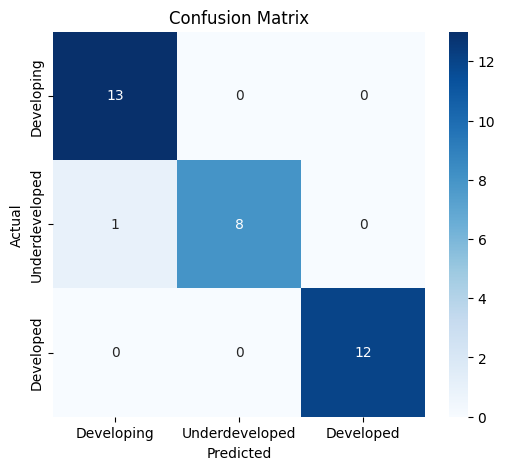

In [12]:
# confusion matrix visualization
plt.figure(figsize=(6,5))
sns.heatmap(cm , fmt='d' , annot=True , cmap='Blues' ,
xticklabels=['Developing','Underdeveloped','Developed'],
            yticklabels=['Developing','Underdeveloped','Developed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('plots/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


### Feature Importance

In [13]:
# feature imporatance chart
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

                       Feature  Importance
4    net_income_per_capita_usd    0.380331
0     child_mortality_per_1000    0.256655
8           gdp_per_capita_usd    0.112723
5       inflation_rate_percent    0.088462
6        life_expectancy_years    0.059613
1          exports_gdp_percent    0.037894
3          imports_gdp_percent    0.025896
2  health_spending_gdp_percent    0.021120
7         total_fertility_rate    0.017306


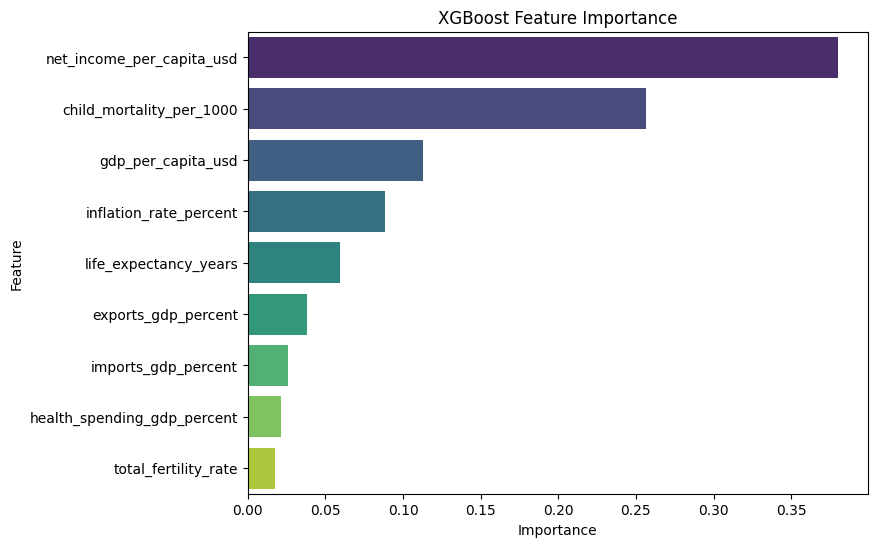

In [14]:
# feature importance bar chart

plt.figure(figsize=(8,6))
sns.barplot(data=importance , x='Importance' , y = 'Feature' , 
            hue = 'Feature' ,
            palette='viridis' , legend=False)
plt.title("XGBoost Feature Importance")
plt.savefig('plots/09_feature_importance.png' , dpi=150 , 
            bbox_inches='tight')
plt.show()

### Save the file

In [15]:
import joblib

joblib.dump(xgb_model , "xgb_country_classifier.pkl")


['xgb_country_classifier.pkl']

In [16]:
import json

cluster_mapping = {0: "Developing", 1: "Under Developed", 2: "Developed"}
with open('cluster_mapping.json', 'w') as f:
    json.dump(cluster_mapping, f)